# Python Computer Vision EP1: สอนตรวจจับวัตถุ(object detection)ด้วย YOLOV12
 Youtube: LouisMakerLab

In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2
%matplotlib inline


# โหลดโมเดล YOLO
model = YOLO("yolo12n.pt")

# เส้นทางรูปภาพ
img_path = ["./datasets/coco8/images/8.jpeg", ] # เปลี่ยนเป็นเส้นทางของรูปภาพที่ต้องการทดสอบ
img_path = "D:\\LogWood Detection\\PythonComputerVision\\YOLO-Detection\\drive-download-20251117T134633Z-1-001"  # เปลี่ยนเป็นเส้นทางของ folder ที่ต้องการทดสอบ

# Run inference with the YOLO12n model on the 'bus.jpg' image
results = model(source=img_path, save=True, device='cpu', conf=0.3) # ถ้ามี webcam ให้ใส่ source=0, ถ้ามีการ์ดจอ device=0
for r in results:
    annotated = r.plot() 
    cv2.imshow("Detection Result", annotated)
    cv2.waitKey(0)
    cv2.destroyAllWindows()



image 1/17 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_20251022092218_@72.jpg: 384x640 1 truck, 61.8ms
image 2/17 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_20251022175653_@72.jpg: 384x640 (no detections), 55.0ms
image 3/17 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_20251023061057_@72.jpg: 384x640 1 train, 41.8ms
image 4/17 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_20251023074636_@72.jpg: 384x640 (no detections), 34.4ms
image 5/17 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_20251024102926_@72.jpg: 384x640 (no detections), 59.4ms
image 6/17 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_202510241

In [5]:
for r in results:
    # print(r)
    for box in r.boxes:
        # print(box)
        rounded_bbox = [round(x) for x in box.xyxy[0].tolist()]
        print(f"Class: {r.names[int(box.cls[0])]}, Confidence: {box.conf[0]:.2f}, BBox: {rounded_bbox}")

Class: truck, Confidence: 0.74, BBox: [1603, 91, 2407, 895]
Class: train, Confidence: 0.41, BBox: [4, 777, 1073, 1003]
Class: truck, Confidence: 0.53, BBox: [971, 0, 2471, 1070]
Class: truck, Confidence: 0.40, BBox: [1001, 0, 2519, 1064]
Class: person, Confidence: 0.54, BBox: [2514, 578, 2605, 769]
Class: truck, Confidence: 0.33, BBox: [1, 542, 772, 959]
Class: truck, Confidence: 0.85, BBox: [1587, 109, 2413, 906]
Class: truck, Confidence: 0.41, BBox: [2, 543, 910, 966]
Class: person, Confidence: 0.34, BBox: [2463, 574, 2572, 732]
Class: truck, Confidence: 0.78, BBox: [997, 2, 2484, 1075]
Class: truck, Confidence: 0.49, BBox: [979, 4, 2434, 1090]
Class: truck, Confidence: 0.68, BBox: [1527, 60, 2325, 931]
Class: potted plant, Confidence: 0.37, BBox: [1719, 306, 2308, 878]
Class: truck, Confidence: 0.61, BBox: [1659, 97, 2443, 863]
Class: truck, Confidence: 0.61, BBox: [1779, 172, 2390, 843]



image 1/1 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_20251026125026_@72.jpg: 384x640 1 truck, 85.6ms
Speed: 1.9ms preprocess, 85.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_20251026125026_@72.jpg: 384x640 1 truck, 60.7ms
Speed: 1.4ms preprocess, 60.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 D:\LogWood Detection\PythonComputerVision\YOLO-Detection\drive-download-20251117T134633Z-1-001\_Channel8_main_20251026125026_@72.jpg: 384x640 (no detections), 68.1ms
Speed: 1.4ms preprocess, 68.1ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


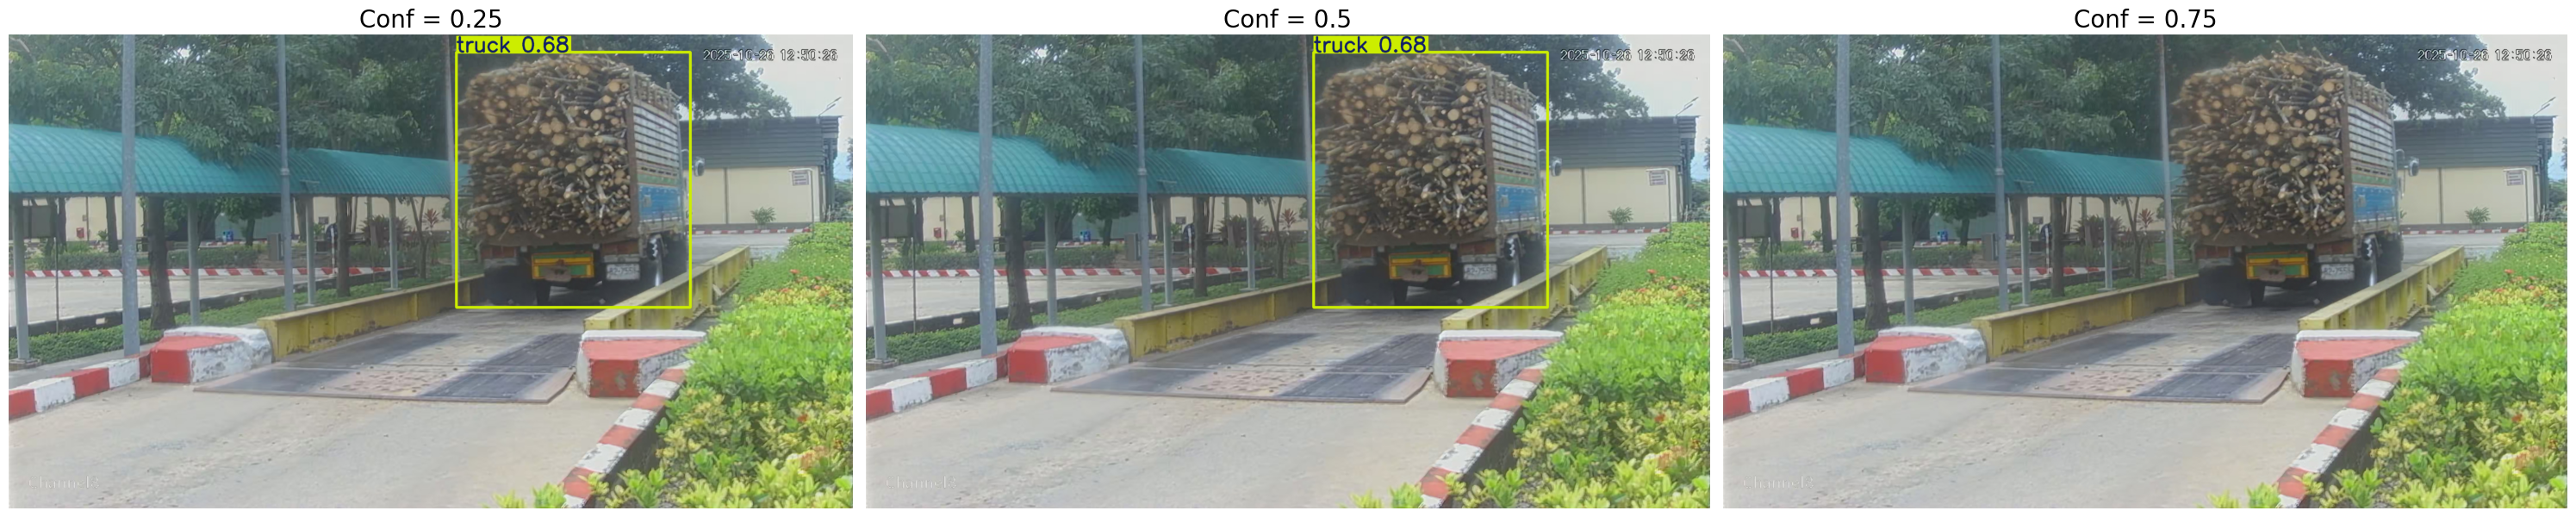

In [8]:
# ค่าความมั่นใจที่ต้องการทดสอบ
conf_levels = [0.25, 0.5, 0.75]
# สร้าง list เพื่อเก็บภาพผลลัพธ์แต่ละระดับ conf
annotated_images = []

# วนลูปรันโมเดลด้วยความมั่นใจต่าง ๆ
for conf in conf_levels:
    results = model(source="D:\\LogWood Detection\\PythonComputerVision\\YOLO-Detection\\drive-download-20251117T134633Z-1-001\\ห้องชั่งไม_Channel8_main_20251026125026_@72.jpg", conf=conf, device='cpu')
    annotated = results[0].plot()  # ได้ภาพแบบ array ที่มี bounding box
    annotated_images.append((conf, annotated))

# แสดงผลลัพธ์ทั้งหมดใน subplot
plt.figure(figsize=(30, 10))
for i, (conf, img) in enumerate(annotated_images):
    plt.subplot(1, len(conf_levels), i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # แปลงสี BGR เป็น RGB
    plt.title(f"Conf = {conf}", fontsize=20)
    plt.axis("off")

plt.tight_layout()
plt.show()
